<a href="https://colab.research.google.com/github/iMuhammadAbdullahAwan/Computer_Vision/blob/main/Quiz_2/Dollar_Bill_Detection_Quiz2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Required Libraries
This cell imports all necessary libraries for data handling, visualization, and building a convolutional neural network using TensorFlow and Keras.


In [ ]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### Extract the Dataset
This cell extracts the compressed dataset of dollar bill images into a working directory and confirms the extraction path.


In [ ]:
zip_path = "Bill_dataset.zip"   # change name if needed
base_dir = "data"

os.makedirs(base_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_dir)

original_data_dir = os.path.join(base_dir, os.listdir(base_dir)[0])
print("Dataset extracted to:", original_data_dir)

Dataset extracted to: data/Bill_dataset


### Create Training and Testing Directories
This cell creates separate directories for training and testing datasets, which will be populated in later steps.


In [ ]:
train_dir = "train"
test_dir = "test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

### Split Dataset into Training and Testing Sets
This cell randomly selects a fixed number of images per class for testing.  
The remaining images are assigned to the training set.


In [ ]:
TEST_IMAGES_PER_CLASS = 5

for class_name in os.listdir(original_data_dir):
    class_path = os.path.join(original_data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    test_images = images[:TEST_IMAGES_PER_CLASS]
    train_images = images[TEST_IMAGES_PER_CLASS:]

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_dir, class_name, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(test_dir, class_name, img)
        )

print("Train–Test split completed")

Train–Test split completed


### Prepare Image Data Generators
This cell defines image preprocessing and augmentation steps for training data.  
It also initializes data generators to load images directly from directories.


In [ ]:
img_size = (128, 128)
batch_size = 16

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 142 images belonging to 4 classes.
Found 19 images belonging to 4 classes.


### Build the Convolutional Neural Network (CNN)
This cell defines and compiles a CNN model with multiple convolutional layers, pooling layers, and fully connected layers for classification.


In [ ]:
num_classes = train_data.num_classes

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Model Optimization

To improve the accuracy of the CNN model, optimization techniques were applied during the training process. Initially, the model was trained with fewer epochs, which can lead to underfitting.

### Increasing Number of Epochs
The number of training epochs was increased to allow the model to learn better feature representations from the dataset. Training for more epochs helps the model converge and improves classification performance.

```python
epochs = 25
history = model.fit(train_data, epochs=epochs)


In [ ]:
epochs = 25   # increased epochs for better learning

history = model.fit(
    train_data,
    epochs=epochs
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 636ms/step - accuracy: 0.4834 - loss: 1.6474
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 564ms/step - accuracy: 0.6030 - loss: 1.2298
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 717ms/step - accuracy: 0.6160 - loss: 0.9987
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 569ms/step - accuracy: 0.6033 - loss: 0.8835
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 725ms/step - accuracy: 0.7855 - loss: 0.6703
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 566ms/step - accuracy: 0.7964 - loss: 0.4821
Epoch 7/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 720ms/step - accuracy: 0.8496 - loss: 0.4062
Epoch 8/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 571ms/step - accuracy: 0.8814 - loss: 0.4781
Epoch 9/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 621ms/step - accuracy: 0.8703 - loss: 0.3287
Epoch 10/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 560ms/step - accuracy: 0.8386 - loss: 0.4056
Epoch 11/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 737ms/step - accuracy: 0.8887 - loss: 0.3432
Epoch 12/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 569ms/step - accuracy: 0.9065 - l

### Evaluate Model Performance
This cell evaluates the trained model on the test dataset and prints the overall classification accuracy.


In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8322 - loss: 3.5897 
Test Accuracy: 0.8421052694320679


### Visualize Predictions
This cell displays sample test images along with their true labels and the model’s predicted labels for qualitative evaluation.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


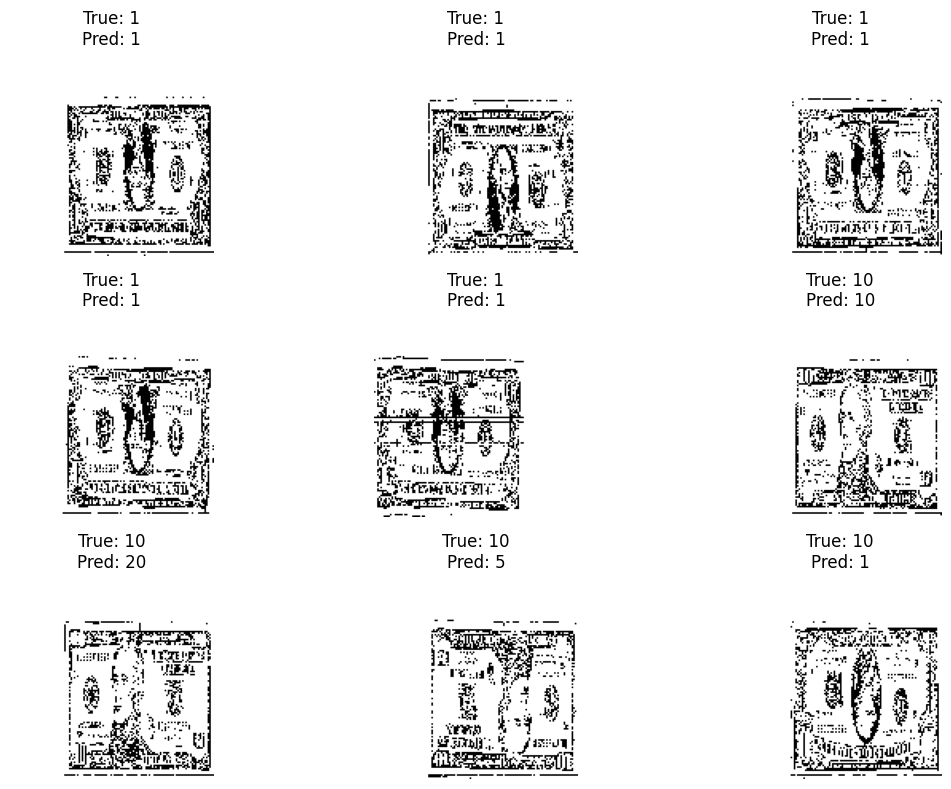

In [ ]:
class_labels = {v: k for k, v in train_data.class_indices.items()}

test_data.reset()
images, labels = next(test_data)
predictions = model.predict(images)

plt.figure(figsize=(12, 8))

for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    true_label = class_labels[np.argmax(labels[i])]
    pred_label = class_labels[np.argmax(predictions[i])]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()